### Lisensi

Teks ini disediakan di bawah lisensi Creative Commons Attribution (CC-BY).
Semua kode tersedia di bawah lisensi MIT yang disetujui FSF.
(c) Kyle T. Mandli


# Review: Finite Differences (Beda Hingga)

Finite differences (beda hingga) adalah ekspresi yang digunakan untuk **mendekati turunan suatu fungsi** yang dihitung pada sekumpulan titik tertentu, yang sering disebut *stencil*.

Bentuk finite difference bisa bermacam-macam, tergantung:

* jenis stencil,
* orde akurasi,
* orde turunan yang dihitung.

Pada materi ini kita akan membahas:

* cara menurunkan finite difference,
* analisis error,
* penerapannya.


## Penurunan Finite Difference

Pendekatan umum untuk menurunkan finite difference biasanya sudah familiar, terutama untuk turunan orde pertama.

Misalkan kita ingin mendefinisikan turunan di titik $(x_i)$:

$$
u'(x_i) = \lim_{\Delta x \to 0}
$$

Ada tiga pendekatan utama:

* **Forward difference (maju)**
  $$
  D_+ u(x_i) = \frac{u(x_i + \Delta x) - u(x_i)}{\Delta x}
  $$

* **Central difference (tengah)**
  $$
  D_0 u(x_i) = \frac{u(x_i + \Delta x) - u(x_i - \Delta x)}{2\Delta x}
  $$

* **Backward difference (mundur)**
  $$
  D_- u(x_i) = \frac{u(x_i) - u(x_i - \Delta x)}{\Delta x}
  $$

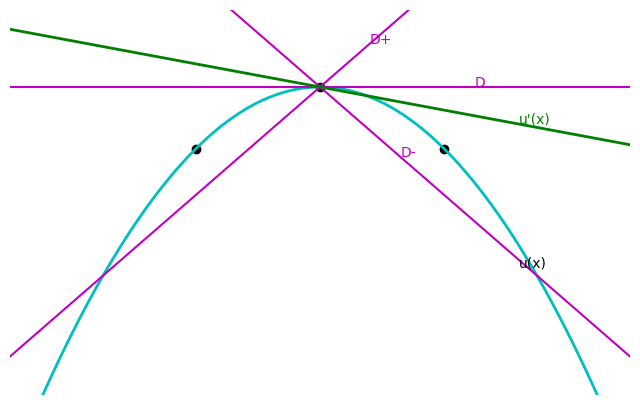

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# fungsi kurva u(x)
def u(x):
    return -0.2*(x-5)**2 + 4

# domain kurva
x = np.linspace(0,10,400)
y = u(x)

# tiga titik pada kurva
x1, x2, x3 = 3, 5, 7
y1, y2, y3 = u(x1), u(x2), u(x3)

# fungsi garis lurus
def line(x, x0, y0, m):
    return m*(x-x0) + y0

x_line = np.linspace(0,10,100)

plt.figure(figsize=(8,5))

# kurva u(x)
plt.plot(x, y, 'c', linewidth=2)
plt.scatter([x1,x2,x3],[y1,y2,y3], color='black')

# garis magenta (D+, D, D-)
plt.plot(x_line, line(x_line,x2,y2,0.7), 'm')
plt.plot(x_line, line(x_line,x2,y2,0), 'm')
plt.plot(x_line, line(x_line,x2,y2,-0.7), 'm')

# garis hijU u'(x)
plt.plot(x_line, line(x_line,x2,y2,-0.15), 'g', linewidth=2)

# label
plt.text(5.8, line(5.8,x2,y2,0.7), "D+", color='m')
plt.text(7.5, line(7.5,x2,y2,0), "D", color='m')
plt.text(6.3, line(6.3,x2,y2,-0.7), "D-", color='m')
plt.text(8.2, line(8.2,x2,y2,-0.15), "u'(x)", color='g')
plt.text(8.2, u(8.2)-0.3, "u(x)", color='k')

plt.xlim(0,10)
plt.ylim(0,5)
plt.axis('off')

plt.show()

Gambar tersebut menggambarkan konsep **kemiringan garis terhadap suatu fungsi (u(x))** pada sebuah titik, yang sering digunakan dalam pembahasan **turunan dan konsep *subderivative* / *superderivative*** pada analisis atau **Persamaan Diferensial Parsial (PDE)**.

### 1. Kurva $(u(x))$

Garis **hitam melengkung** adalah fungsi $(u(x))$.
Kurva ini menunjukkan bagaimana nilai fungsi berubah terhadap variabel $(x)$.

Tiga **titik hitam** adalah titik-titik tertentu pada kurva yang sedang dianalisis.

### 2. Garis biru $(u'(x))$

Garis **biru** menunjukkan **garis singgung (tangent line)** di titik tengah.

Kemiringan garis ini adalah **turunan fungsi di titik tersebut**:

$$
u'(x)
$$

Artinya:

* garis ini adalah **kemiringan sebenarnya dari kurva** pada titik itu.

### 3. Garis merah $(D^+), (D), dan (D^-)$

Garis merah menunjukkan **kemungkinan kemiringan garis lain** yang melewati titik tersebut.

* **$(D^+)$** → garis dengan kemiringan **lebih besar (lebih curam ke atas)**
* **$(D)$** → garis dengan kemiringan **mendekati garis singgung**
* **$(D^-)$** → garis dengan kemiringan **lebih kecil (lebih turun)**

Secara konsep:

$$
D^- \leq u'(x) \leq D^+
$$

Artinya turunan fungsi berada **di antara batas kemiringan atas dan bawah**.

### 4. Makna matematis gambar

Gambar ini biasanya digunakan untuk menjelaskan:

* **batas kemiringan garis terhadap fungsi**
* konsep **superdifferential dan subdifferential**
* pendekatan turunan ketika fungsi **tidak selalu halus**
* konsep dalam **viscosity solution pada PDE**

Intinya:

**Turunan $(u'(x))$ adalah kemiringan garis singgung yang berada di antara berbagai kemungkinan garis lain yang melalui titik tersebut.**

Jika $(\Delta x)$ tidak menuju nol (tetapi kecil), maka rumus-rumus ini menjadi **aproksimasi turunan**.

Selanjutnya kita akan membahas cara yang lebih sistematis untuk:

* mendapatkan aproksimasi orde lebih tinggi,
* turunan orde lebih tinggi,
* memahami error dari aproksimasi.

## Polinom Interpolasi

Salah satu cara menurunkan finite difference adalah dengan membuat **polinom interpolasi** melalui titik-titik stencil, lalu menurunkannya.

Misalkan kita punya (N+1) titik:
$$
(x_0, u(x_0)), (x_1, u(x_1)), \dots, (x_N, u(x_N))
$$

Polinom interpolasinya:
$$
P_N(x) = \sum_{i=0}^{N} u(x_i),\ell_i(x)
$$

di mana $(\ell_i(x))$ adalah polinom basis Lagrange.
$$
    \ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{x - x_0}{x_i - x_0} \frac{x - x_1}{x_i - x_1} \cdots \frac{x - x_{i-1}}{x_i - x_{i-1}}\frac{x - x_{i+1}}{x_i - x_{i+1}} \cdots \frac{x - x_{N}}{x_i - x_{N}}
$$

Sifat penting:

* $(\ell_i(x_i) = 1)$
* $(\ell_i(x_j) = 0) untuk (j \ne i)$

Karena kita tahu cara menurunkan polinom, kita bisa langsung mendapatkan finite difference dari sini.

### Contoh: **Stencil 2 Titik**

Misalkan kita memiliki **dua titik** untuk membentuk pendekatan terhadap turunan. Polinom interpolasi yang melalui dua titik adalah **fungsi linear** dengan bentuk

$$
P_1(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} + u(x_1) \frac{x - x_0}{x_1 - x_0}.
$$

Turunkan pendekatan turunan yang **berpusat di $(x_0)$** dari polinom ini.

Dengan menurunkan $(P_1(x))$, kita memperoleh

$$
P'_1(x) = u(x_0) \frac{1}{x_0 - x_1} + u(x_1) \frac{1}{x_1 - x_0}.
$$

Jika jarak antara $(x_0)$ dan $(x_1)$ dinyatakan sebagai

$$
\Delta x = x_1 - x_0
$$

maka persamaan tersebut dapat dituliskan sebagai

$$
P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}.
$$

Bentuk ini merupakan **bentuk umum dari pendekatan turunan** $(D_-u(x))$ dan $(D_+u(x))$ 


### Perluasan ke **Tiga Titik**

Jika kita memperluas pendekatan ini menjadi **tiga titik**, maka polinom interpolasi yang diperoleh adalah

$$
    P_2(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + u(x_1) \frac{x - x_0}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + u(x_2) \frac{x - x_0}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1}.
$$

Jika polinom ini diturunkan, maka diperoleh

$$
\begin{aligned}
P'_2(x) &= u(x_0)\left(\frac{1}{x_0-x_1}\frac{x-x_2}{x_0-x_2}+\frac{x-x_1}{x_0-x_1}\frac{1}{x_0-x_2}\right) \
&+ u(x_1)\left(\frac{1}{x_1-x_0}\frac{x-x_2}{x_1-x_2}+\frac{x-x_0}{x_1-x_0}\frac{1}{x_1-x_2}\right) \
&+ u(x_2)\left(\frac{1}{x_2-x_0}\frac{x-x_1}{x_2-x_1}+\frac{x-x_0}{x_2-x_0}\frac{1}{x_2-x_1}\right).
\end{aligned}
$$

Jika kita menggunakan jarak grid seragam $(\Delta x)$, maka bentuknya menjadi

$$
\begin{aligned}
P'_2(x) &=
u(x_0)\left(\frac{x-x_2}{2\Delta x^2}+\frac{x-x_1}{2\Delta x^2}\right) \
&+ u(x_1)\left(\frac{x-x_2}{-\Delta x^2}+\frac{x-x_0}{-\Delta x^2}\right) \
&+ u(x_2)\left(\frac{x-x_1}{2\Delta x^2}+\frac{x-x_0}{2\Delta x^2}\right).
\end{aligned}
$$

Kemudian disederhanakan menjadi

$$
\begin{aligned}
P'_2(x) &=
\frac{u(x_0)}{2\Delta x^2}(2x-x_2-x_1)

+\frac{u(x_1)}{-\Delta x^2}(2x-x_2-x_0)
+ \frac{u(x_2)}{2\Delta x^2}(2x-x_1-x_0).
  \end{aligned}
  $$


### Evaluasi Turunan di Titik Tengah

Jika turunan ini dievaluasi di **titik tengah $(x_1)$** (diasumsikan sebagai titik pusat), maka diperoleh

$$
\begin{aligned}
P'_2(x_1) &=
\frac{u(x_0)}{2\Delta x^2}(x_1-x_2)

+ \frac{u(x_1)}{-\Delta x^2}(x_1-x_2+x_1-x_0)
+ \frac{u(x_2)}{\Delta x^2}(x_1-x_0)
  \end{aligned}
  $$

Karena

$$
x_1-x_2=-\Delta x, \quad x_1-x_0=\Delta x
$$

maka persamaan tersebut menjadi

$$
\begin{aligned}
P'_2(x_1)
&= \frac{u(x_0)}{2\Delta x^2}(-\Delta x)

+ \frac{u(x_1)}{-\Delta x^2}(-\Delta x+\Delta x)
+ \frac{u(x_2)}{\Delta x^2}(2\Delta x).
  \end{aligned}
  $$

Sehingga hasil akhirnya adalah

$$
P'_2(x_1) = \frac{u(x_2)-u(x_0)}{2\Delta x}.
$$

Hasil ini memberikan **pendekatan turunan dengan tiga titik (central difference)** yang merupakan **pendekatan ketiga**

**tambahan:**

* **2 titik → menghasilkan pendekatan turunan forward/backward difference**
* **3 titik → menghasilkan pendekatan turunan central difference yang lebih akurat**

## Metode Deret Taylor

Cara lain menurunkan finite difference adalah menggunakan **deret Taylor** dan metode koefisien tak tentu.

Ekspansi Taylor:

$$u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)$$

Misalkan kita ingin menurunkan **pendekatan turunan pertama dengan akurasi orde dua** seperti yang diperoleh sebelumnya. Pendekatan ini memerlukan nilai pada titik  
$(x_{n+1}, u(x_{n+1}))$ dan $(x_{n-1}, u(x_{n-1}))$.

Nilai-nilai tersebut dapat dinyatakan menggunakan **deret Taylor** sebagai berikut:

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n) + (x_{n+1}-x_n)u'(x_n) + \frac{(x_{n+1}-x_n)^2}{2!}u''(x_n) + \frac{(x_{n+1}-x_n)^3}{3!}u'''(x_n) + \mathcal{O}((x_{n+1}-x_n)^4) \\
&= u(x_n) + \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) + \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

dan

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n) + (x_{n-1}-x_n)u'(x_n) + \frac{(x_{n-1}-x_n)^2}{2!}u''(x_n) + \frac{(x_{n-1}-x_n)^3}{3!}u'''(x_n) + \mathcal{O}((x_{n-1}-x_n)^4) \\
&= u(x_n) - \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) - \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

Sekarang, untuk membentuk ekspresi turunan, kita mengasumsikan pendekatan berikut

$$
u'(x_n) + R(x_n) = A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

dengan $R(x_n)$ adalah **galat (error)**.

Dengan memasukkan ekspansi Taylor di atas diperoleh

$$
\begin{aligned}
u'(x_n) + R(x_n) &= A\left(u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) + \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)\right) \\
&+ B\,u(x_n) + C\left(u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) - \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)\right)
\end{aligned}
$$

Karena kita menginginkan

$$
R(x_n) = \mathcal{O}(\Delta x^2)
$$

maka semua suku berorde lebih rendah harus hilang kecuali suku yang mengalikan $u'(x_n)$.

Dengan mengelompokkan suku-suku berdasarkan turunan yang sama diperoleh sistem persamaan

$$
\begin{aligned}
u(x_n): & \quad A + B + C = 0 \\
u'(x_n): & \quad A \Delta x - C \Delta x = 1 \\
u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 0
\end{aligned}
$$

Dari persamaan terakhir diperoleh

$$
A = -C
$$

Substitusi ke persamaan kedua menghasilkan

$$
A = \frac{1}{2\Delta x}, \qquad C = -\frac{1}{2\Delta x}
$$

Kemudian dari persamaan pertama diperoleh

$$
B = 0
$$

Sehingga pendekatan turunannya adalah

$$
u'(x_n) + R(x_n) =
\frac{u(x_{n+1}) - u(x_{n-1})}{2\Delta x}
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
$$

Galatnya adalah

$$
R(x_n) =
\frac{\Delta x^2}{3!}u'''(x_n) + \mathcal{O}(\Delta x^3)
= \mathcal{O}(\Delta x^2)
$$

Artinya pendekatan ini memiliki **akurasi orde dua terhadap $\Delta x$**.

## Contoh: Turunan Orde Pertama (Kode)

Kode berikut menghitung turunan fungsi sinus menggunakan finite difference, lalu membandingkan dengan turunan aslinya.

delta_x = 0.6613879270715355


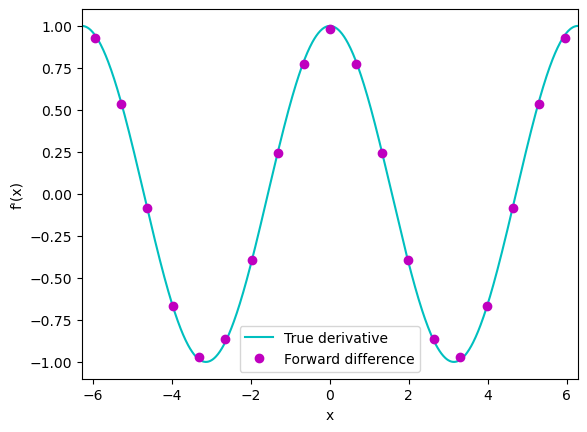

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan fungsi dan turunan sebenarnya
f = lambda x: np.sin(x)
f_prime = lambda x: np.cos(x)

# Menggunakan diskretisasi seragam
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

N = 20
x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)

delta_x = x_hat[1] - x_hat[0]
print("delta_x =", delta_x)

# Menghitung turunan menggunakan metode forward difference dengan loop
f_prime_hat = np.empty(x_hat.shape)

for i in range(N - 1):
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x

# Menggunakan backward difference untuk titik terakhir
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1,1,1)

# Turunan sebenarnya
axes.plot(x, f_prime(x), 'c', label="True derivative")

# Turunan numerik hasil forward difference
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'mo', label="Forward difference")

axes.set_xlim((x[0], x[-1]))
axes.set_ylim((-1.1, 1.1))
axes.set_xlabel("x")
axes.set_ylabel("f'(x)")
axes.legend()

plt.show()

## Penurunan Rumus Turunan Kedua (Second Order Accurate)

Kita ingin mencari pendekatan numerik untuk **turunan kedua** $u''(x_n)$ menggunakan tiga titik:
- $x_{n-1}$
- $x_n$
- $x_{n+1}$

dengan jarak grid seragam

$$
\Delta x = x_{n+1} - x_n = x_n - x_{n-1}
$$

Pendekatan ini diperoleh menggunakan **ekspansi deret Taylor** di sekitar titik $x_n$.

### 1. Ekspansi Taylor di sekitar $x_n$

Ekspansi Taylor untuk $u(x_{n+1})$:

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n)
+ \Delta x\,u'(x_n)
+ \frac{\Delta x^2}{2}u''(x_n)
+ \frac{\Delta x^3}{6}u'''(x_n)
+ \frac{\Delta x^4}{24}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^5)
\end{aligned}
$$

Ekspansi Taylor untuk $u(x_{n-1})$:

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n)
- \Delta x\,u'(x_n)
+ \frac{\Delta x^2}{2}u''(x_n)
- \frac{\Delta x^3}{6}u'''(x_n)
+ \frac{\Delta x^4}{24}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^5)
\end{aligned}
$$


### 2. Membentuk kombinasi linear

Kita asumsikan pendekatan turunan kedua memiliki bentuk

$$
u''(x_n) + R(x_n) =
A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

dengan

- $A, B, C$ = koefisien yang ingin dicari  
- $R(x_n)$ = galat (error)


### 3. Substitusi ekspansi Taylor

Masukkan ekspansi Taylor ke dalam persamaan:

$$
\begin{aligned}
u''(x_n) + R(x_n)
&= A\Big[u(x_n)+\Delta x u'(x_n)+\frac{\Delta x^2}{2}u''(x_n)
+\frac{\Delta x^3}{6}u'''(x_n)+\frac{\Delta x^4}{24}u^{(4)}(x_n)\Big] \\
&+ B\,u(x_n) \\
&+ C\Big[u(x_n)-\Delta x u'(x_n)+\frac{\Delta x^2}{2}u''(x_n)
-\frac{\Delta x^3}{6}u'''(x_n)+\frac{\Delta x^4}{24}u^{(4)}(x_n)\Big]
\end{aligned}
$$


### 4. Mengelompokkan suku yang sama

Kelompokkan berdasarkan turunan:

Suku $u(x_n)$

$$
A + B + C
$$

Suku $u'(x_n)$

$$
A\Delta x - C\Delta x
$$

Suku $u''(x_n)$

$$
A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2}
$$


### 5. Menentukan syarat koefisien

Agar pendekatan menghasilkan $u''(x_n)$, maka:

(1) Suku $u(x_n)$ harus hilang

$$
A + B + C = 0
$$

(2) Suku $u'(x_n)$ harus hilang

$$
A\Delta x - C\Delta x = 0
$$

(3) Suku $u''(x_n)$ harus bernilai 1

$$
A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2} = 1
$$


### 6. Menyelesaikan sistem persamaan

Dari persamaan kedua:

$$
A = C
$$

Masukkan ke persamaan ketiga:

$$
A\frac{\Delta x^2}{2} + A\frac{\Delta x^2}{2} = 1
$$

$$
A\Delta x^2 = 1
$$

$$
A = \frac{1}{\Delta x^2}
$$

Karena $A=C$, maka

$$
C = \frac{1}{\Delta x^2}
$$


### 7. Menentukan $B$

Gunakan persamaan pertama

$$
A + B + C = 0
$$

$$
\frac{1}{\Delta x^2} + B + \frac{1}{\Delta x^2} = 0
$$

$$
B = -\frac{2}{\Delta x^2}
$$


### 8. Memasukkan kembali ke rumus awal

Sehingga diperoleh

$$
u''(x_n) \approx
\frac{1}{\Delta x^2}u(x_{n+1})
-\frac{2}{\Delta x^2}u(x_n)
+\frac{1}{\Delta x^2}u(x_{n-1})
$$

atau

$$
u''(x_n) \approx
\frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
$$


### 9. Galat pendekatan

Jika suku orde lebih tinggi diperhitungkan, maka galatnya adalah

$$
R(x_n) =
\frac{\Delta x^2}{12}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^3)
$$


### 10. Kesimpulan

Rumus turunan kedua dengan **finite difference central** adalah

$$
u''(x_n) =
\frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
$$

dengan galat

$$
\mathcal{O}(\Delta x^2)
$$

Artinya metode ini memiliki **akurasi orde dua (second-order accurate)**.

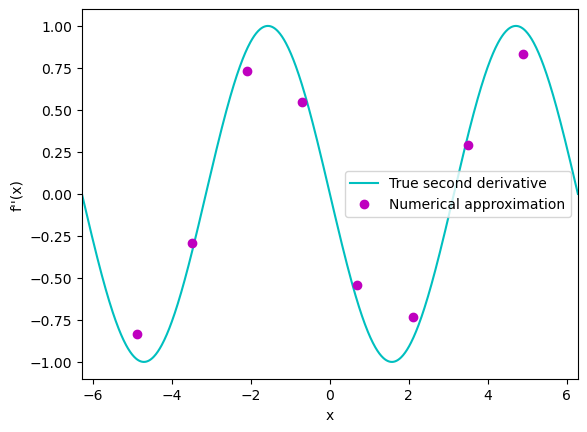

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan fungsi dan turunan keduanya yang sebenarnya
f = lambda x: np.sin(x)
f_dubl_prime = lambda x: -np.sin(x)

# Menggunakan diskretisasi seragam
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

N = 10
x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)

delta_x = x_hat[1] - x_hat[0]

# Menghitung pendekatan turunan kedua
f_dubl_prime_hat = np.empty(x_hat.shape)

# Central difference untuk titik tengah
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)

# Menggunakan formula khusus untuk titik di tepi domain
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / (delta_x**2)
f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / (delta_x**2)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1,1,1)

# Turunan kedua sebenarnya
axes.plot(x, f_dubl_prime(x), 'c', label="True second derivative")

# Hasil pendekatan numerik
axes.plot(x_hat, f_dubl_prime_hat, 'mo', label="Numerical approximation")

axes.set_xlim((x[0], x[-1]))
axes.set_ylim((-1.1, 1.1))
axes.set_xlabel("x")
axes.set_ylabel("f''(x)")
axes.legend()

plt.show()

# Penurunan Umum (General Derivation)

Untuk pendekatan **finite difference secara umum**, kita ingin menghitung turunan ke-$k$ dari suatu fungsi pada titik $\bar{x}$.

Misalkan kita memiliki **stencil** yang terdiri dari $N$ titik

$$
x_1, x_2, \ldots, x_N
$$

dengan syarat

$$
N \ge k + 1
$$

Artinya jumlah titik harus **minimal satu lebih banyak dari orde turunan** yang ingin dihitung.

Contoh:

* Turunan pertama ($k=1$) → minimal **2 titik**
* Turunan kedua ($k=2$) → minimal **3 titik**

Biasanya $\bar{x}$ adalah salah satu titik stencil, tetapi **ini tidak wajib**.
Kita juga mengasumsikan bahwa fungsi $u(x)$ **cukup halus (smooth)** sehingga **ekspansi Taylor berlaku**.


### 1. Ekspansi Taylor pada setiap titik stencil

Pada setiap titik $x_i$ kita dapat menuliskan **ekspansi Taylor di sekitar $\bar{x}$**

$$
u(x_i) =
u(\bar{x})

* (x_i-\bar{x})u'(\bar{x})
* \frac{(x_i-\bar{x})^2}{2!}u''(\bar{x})
* \cdots
* \frac{(x_i-\bar{x})^k}{k!}u^{(k)}(\bar{x})
* \cdots
  $$

Artinya nilai fungsi di titik $x_i$ dapat ditulis sebagai kombinasi dari:

* nilai fungsi di $\bar{x}$
* turunan pertama
* turunan kedua
* turunan yang lebih tinggi

Ini adalah **langkah dasar dari seluruh metode finite difference**.

### 2. Membentuk kombinasi linear

Kita ingin membentuk kombinasi linear dari nilai fungsi pada titik stencil

$$
a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_N u(x_N)
$$

Tujuannya adalah agar kombinasi ini **menghasilkan turunan ke-$k$**:

$$
u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p)

a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_N u(x_N)
$$

dengan

* $a_i$ = koefisien finite difference
* $\mathcal{O}(\Delta x^p)$ = galat metode
* $p$ = orde akurasi metode


### 3. Mengganti dengan ekspansi Taylor

Jika ekspansi Taylor pada langkah sebelumnya kita substitusi ke dalam kombinasi linear, kita memperoleh

$$
\sum_{j=1}^{N} a_j u(x_j)
$$

menjadi

$$

\left(\sum_{j=1}^{N} a_j \right)u(\bar{x})
+
\left(\sum_{j=1}^{N} a_j(x_j-\bar{x})\right)u'(\bar{x})
$$

$$
+
\left(\sum_{j=1}^{N} a_j\frac{(x_j-\bar{x})^2}{2!}\right)u''(\bar{x})

* \cdots
$$

Artinya kombinasi linear tersebut sebenarnya merupakan **kombinasi dari berbagai turunan**.

Padahal yang kita inginkan **hanya turunan ke-$k$**.

Agar pendekatan menghasilkan turunan ke-$k$, kita harus:

1. **Menghilangkan semua turunan yang lebih rendah dari $k$**
2. **Menyisakan hanya turunan ke-$k$**

Artinya koefisien harus memenuhi kondisi tertentu.


### 4. Kondisi matematis untuk koefisien

Syaratnya adalah

$$
\frac{1}{(i - 1)!}
\sum_{j=1}^{N}
a_j (x_j - \bar{x})^{(i-1)}

\begin{cases}
1, & \text{jika } i - 1 = k \
0, & \text{lainnya}
\end{cases}
$$

untuk

$$
i = 1,2,\ldots,N
$$

Persamaan ini berasal dari **menyamakan koefisien pada ekspansi Taylor**, yang berfungsi untuk:

### Menghilangkan nilai fungsi

Untuk $i=1$

$$
\sum a_j = 0
$$

Ini menghilangkan suku

$$
u(\bar{x})
$$


### Menghilangkan turunan pertama

Untuk $i=2$

$$
\sum a_j(x_j-\bar{x}) = 0
$$

Ini menghilangkan

$$
u'(\bar{x})
$$


### Menghilangkan turunan kedua

Untuk $i=3$

$$
\sum a_j(x_j-\bar{x})^2 = 0
$$

Ini menghilangkan

$$
u''(\bar{x})
$$


### Menyisakan turunan ke-$k$

Ketika

$$
i-1 = k
$$

maka

$$
\frac{1}{k!}\sum a_j(x_j-\bar{x})^k = 1
$$

Sehingga suku yang tersisa adalah

$$
u^{(k)}(\bar{x})
$$


### 5. Sistem persamaan yang terbentuk

Semua kondisi tersebut membentuk **sistem persamaan linear**

untuk koefisien

$$
a_1,a_2,\ldots,a_N
$$

yang dapat ditulis dalam bentuk matriks:

$$
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1 \\
(x_1 - \bar{x}) & (x_2 - \bar{x}) & (x_3 - \bar{x}) & \cdots & (x_N - \bar{x}) \\
(x_1 - \bar{x})^2 & (x_2 - \bar{x})^2 & (x_3 - \bar{x})^2 & \cdots & (x_N - \bar{x})^2 \\
\vdots & \vdots & \vdots & \ddots & \vdots
\end{bmatrix}
\begin{bmatrix}
a_1 \\ a_2 \\ a_3 \\ \vdots \\ a_N
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 1 \\ \vdots \\ 0
\end{bmatrix}
$$

### 6. Hubungan dengan Matriks Vandermonde

Matriks di sisi kiri memiliki bentuk khusus yang disebut **Vandermonde matrix**.

Jika semua titik

$$
x_1,x_2,\ldots,x_N
$$

**berbeda**, maka matriks ini memiliki **solusi unik**.

Artinya koefisien finite difference

$$
a_1,a_2,\ldots,a_N
$$

dapat dihitung secara unik.

### 7. Hubungan dengan rumus finite difference yang umum

Dari metode umum ini muncul rumus-rumus yang sering digunakan.

### Turunan pertama (central difference)

$$
u'(x_n) \approx
\frac{u(x_{n+1})-u(x_{n-1})}{2\Delta x}
$$

### Turunan kedua

$$
u''(x_n) \approx
\frac{u(x_{n+1})-2u(x_n)+u(x_{n-1})}{\Delta x^2}
$$

Semua rumus tersebut sebenarnya **hanya kasus khusus dari derivasi umum finite difference** yang telah dijelaskan di atas.

In [15]:
import numpy
import scipy.special

def finite_difference(k, x_bar, x):
    """Menghitung koefisien finite difference untuk turunan ke-k"""

    N = x.shape[0]

    # Membuat matriks Vandermonde
    A = numpy.ones((N, N))

    x_row = x - x_bar

    for i in range(1, N):
        A[i, :] = x_row ** i / scipy.special.factorial(i)

    # Membuat vektor ruas kanan
    b = numpy.zeros(N)
    b[k] = 1.0

    # Menyelesaikan sistem linear
    c = numpy.linalg.solve(A, b)

    return c


print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))
print(finite_difference(1, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))
print(finite_difference(1, -2.0, numpy.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)

[ 1. -2.  1.]
[-0.5  0.   0.5]
[-2.08333333  4.         -3.          1.33333333 -0.25      ]
[ 10. -15.  -4.  14.  -6.   1.]


# Analisis Galat (Error Analysis)

Kita mengetahui dari **Teorema Lagrange** bahwa suku sisa (*remainder term*) dari interpolasi polinomial memiliki bentuk

$$
R_N(x) = (x - x_0)(x - x_1)\cdots (x - x_{N})(x - x_{N+1}) \frac{u^{(N+1)}(c)}{(N+1)!}
$$

dengan syarat bahwa fungsi

$$
u(x) \in C^{N+1}
$$

pada interval yang kita perhatikan.

Artinya fungsi $u(x)$ harus memiliki **turunan kontinu hingga orde $N+1$** agar ekspansi ini valid.


## Turunan dari polinomial interpolasi

Jika kita mengambil turunan dari **polinomial interpolasi $P_N(x)$** (yang ditulis menggunakan **polinom Newton**), maka diperoleh

$$\begin{aligned}
    P_N'(x) &= [u(x_0), u(x_1)] + ((x - x_1) + (x - x_0)) [u(x_0), u(x_1), u(x_2)]+ \cdots \\
    &\quad  + \left(\sum^{N-1}_{i=0}\left( \prod^{N-1}_{j=0,~j\neq i} (x - x_j) \right )\right ) [u(x_0), u(x_1), \ldots, u(x_N)]
\end{aligned}$$


di mana

* $[u(x_0),u(x_1)]$ adalah **divided difference**
* $[u(x_0),u(x_1),u(x_2)]$ adalah **divided difference orde lebih tinggi**

Divided difference adalah cara untuk membangun **polinom interpolasi Newton**.


## Turunan dari suku sisa (remainder)

Secara serupa, kita juga dapat menghitung turunan dari suku sisa

$$
R_N(x)
$$

yang menghasilkan

$$R_N'(x) = \left(\sum^{N}_{i=0} \left( \prod^{N}_{j=0,~j\neq i} (x - x_j) \right )\right ) \frac{u^{(N+1)}(c)}{(N+1)!}$$

Persamaan ini menunjukkan bagaimana **kesalahan (error)** dari interpolasi berubah ketika kita menghitung turunan.


## Aproksimasi turunan pada titik data

Sekarang jika kita menghitung turunan pada salah satu titik data

$$
(x_k, y_k)
$$

maka persamaan sebelumnya menjadi lebih sederhana

$$
u'(x_k) = P_N'(x_k) + R_N'(x_k)
$$

Artinya:

* $P_N'(x_k)$ → turunan dari polinom interpolasi (aproksimasi numerik)
* $R_N'(x_k)$ → galat dari aproksimasi tersebut


## Perkiraan besar galat

Jika kita mendefinisikan

$$
\Delta x = \max_i |x_k - x_i|
$$

yaitu **jarak maksimum antara titik evaluasi dan titik stencil**, maka suku galat memenuhi

$$
R_N'(x_k) = \mathcal{O}(\Delta x^N)
$$

ketika

$$
\Delta x \rightarrow 0
$$


Hasil ini menunjukkan bahwa:

* metode finite difference **akan konvergen**
* semakin kecil $\Delta x$, semakin kecil galatnya
* dengan menambah jumlah titik stencil, kita dapat memperoleh **aproksimasi dengan orde yang lebih tinggi**

Dengan kata lain, kita bisa membuat **aproksimasi turunan dengan akurasi setinggi yang kita inginkan**.

Analisis galat ini menjelaskan bahwa:

1. Turunan numerik sebenarnya berasal dari **turunan polinom interpolasi**
2. Perbedaan antara turunan sebenarnya dan aproksimasi berasal dari **remainder interpolation**
3. Galatnya berorde

$$
\mathcal{O}(\Delta x^N)
$$

yang berarti metode menjadi **semakin akurat ketika grid semakin halus**.

### Galat Pemotongan

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk menemukan *galat pemotongan*.

Sebagai contoh, mari kita pertimbangkan lagi aproksimasi turunan pertama di atas, kita memerlukan ekspansi Taylor
$$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$
dan
$$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

Memasukkan ini ke dalam ekspresi kita, kita dapatkan
$$\begin{aligned}
    D_+ u(\bar{x}) &= \frac{u(\bar{x} + \Delta x) - u(\bar{x})}{\Delta x} \\
    &= \frac{\Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)}{\Delta x} \\
    &= u'(\bar{x}) + \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3).
\end{aligned}$$

Jika kita hitung $D_+ u(\bar{x}) - u'(\bar{x})$, galat pemotongan:

$$
\frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3)
$$

Galat $D_+$: $\mathcal{O}(\Delta x)$, dikontrol oleh $u''(\bar{x})$.

Untuk central difference $D_0 u(\bar{x}) - u'(\bar{x})$:

$$
\frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Galat $D_0$: $\mathcal{O}(\Delta x^2)$, dikontrol oleh $u'''(\bar{x})$.

Perbandingan: $D_0$ lebih akurat dari $D_+$ karena orde galat lebih tinggi.

Untuk turunan kedua, galat central:

$$
\frac{\Delta x^2}{12} u^{(4)}(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Kesimpulan: Finite differences konvergen dengan $\mathcal{O}(\Delta x^p)$, p meningkat dengan titik stencil.

Dari ekspansi Taylor untuk $u(\bar{x} + \Delta x)$ dan $u(\bar{x} - \Delta x)$, substitusi ke $D_0 u(\bar{x}) = \frac{u(\bar{x} + \Delta x) - u(\bar{x} - \Delta x)}{2\Delta x}$ menghasilkan:

$$
D_0 u(\bar{x}) = u'(\bar{x}) + \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Sehingga galat truncation:

$$
D_0 u(\bar{x}) - u'(\bar{x}) = \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

### Derivasi Model Galat untuk Orde Akurasi Grafik

Asumsikan galat truncation $e(\Delta x) = C \Delta x^n$, di mana $n$ adalah orde akurasi.

Ambil logaritma natural:

$$
\log e(\Delta x) = \log C + n \log \Delta x
$$

Ini adalah persamaan garis lurus $y = m x + b$, dengan:

- $y = \log e(\Delta x)$
- $x = \log \Delta x$
- Kemiringan $m = n$ (orde akurasi)
- Intersep $b = \log C$

Untuk menentukan $C$ dari titik pertama $(\Delta x_1, e_1)$:

$$
\log C = \log e_1 - n \log \Delta x_1
$$

$$
C = e^{\log e_1 - n \log \Delta x_1} = \frac{e_1}{(\Delta x_1)^n}
$$

Dengan plot $\log e$ vs $\log \Delta x$, kemiringan memberikan $n$, memungkinkan verifikasi empiris orde konvergensi metode finite difference.

### Galat Pemotongan

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk menemukan *galat pemotongan*.

Sebagai contoh, mari kita pertimbangkan lagi aproksimasi turunan pertama di atas, kita memerlukan ekspansi Taylor
$$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$
dan
$$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

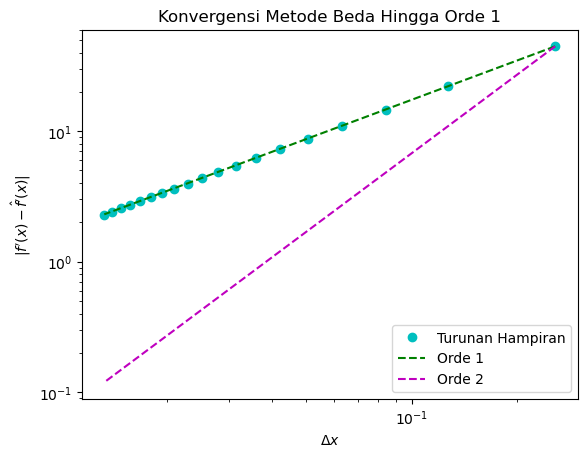

In [8]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: np.sin(x) + x**2 + 3.0 * x**3
f_prime = lambda x: np.cos(x) + 2.0 * x + 9.0 * x**2

delta_x = []
error = []

for N in range(50, 1000, 50):
    x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)
    delta_x.append(x_hat[1] - x_hat[0])

    f_prime_hat = np.empty(x_hat.shape)
    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / delta_x[-1]

    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]

    error.append(np.linalg.norm(np.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat), ord=np.inf))

error = np.array(error)
delta_x = np.array(delta_x)

fig = plt.figure()
axes = fig.add_subplot(1,1,1)

axes.loglog(delta_x, error, 'co', label="Turunan Hampiran")

order_C = lambda delta_x, error, order: np.exp(np.log(error) - order*np.log(delta_x))

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'g--', label="Orde 1")
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'm--', label="Orde 2")

axes.legend(loc=4)
axes.set_title("Konvergensi Metode Beda Hingga Orde 1")
axes.set_xlabel(r"$\Delta x$")
axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")

plt.show()

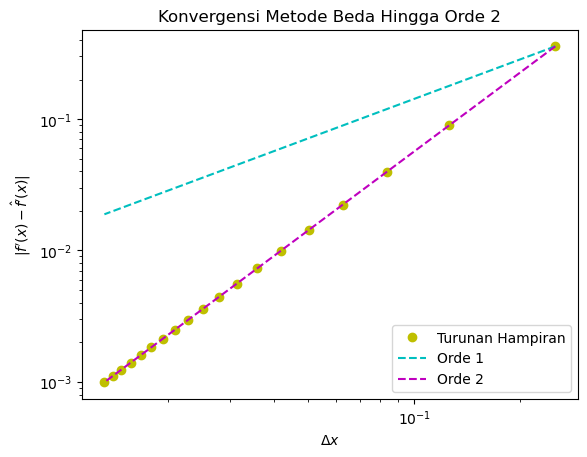

In [19]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: np.sin(x) + x**2 + 3.0 * x**3
f_prime = lambda x: np.cos(x) + 2.0 * x + 9.0 * x**2

delta_x = []
error = []

for N in range(50, 1000, 50):
    x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N + 1)
    delta_x.append(x_hat[1] - x_hat[0])

    # menghitung turunan numerik
    f_prime_hat = np.empty(x_hat.shape)

    # central difference (orde 2)
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])

    # second-order difference di batas
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])
    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])

    error.append(np.linalg.norm(np.abs(f_prime(x_hat) - f_prime_hat), ord=np.inf))

error = np.array(error)
delta_x = np.array(delta_x)

fig = plt.figure()
axes = fig.add_subplot(1,1,1)

axes.loglog(delta_x, error, "yo", label="Turunan Hampiran")

order_C = lambda delta_x, error, order: np.exp(np.log(error) - order*np.log(delta_x))

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'c--', label="Orde 1")
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'm--', label="Orde 2")

axes.legend(loc=4)
axes.set_title("Konvergensi Metode Beda Hingga Orde 2")
axes.set_xlabel(r"$\Delta x$")
axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")

plt.show()